In [1]:
from galaxy_datasets import gz_candels 
    
catalog, label_cols = gz_candels(
        root='.tmp/',
        train=True,
        download=True,
)


In [2]:
catalog.columns.to_numpy()

array(['smooth-or-featured-candels_smooth',
       'smooth-or-featured-candels_features',
       'smooth-or-featured-candels_artifact',
       'how-rounded-candels_completely', 'how-rounded-candels_in-between',
       'how-rounded-candels_cigar-shaped',
       'clumpy-appearance-candels_yes', 'clumpy-appearance-candels_no',
       'disk-edge-on-candels_yes', 'disk-edge-on-candels_no',
       'edge-on-bulge-candels_yes', 'edge-on-bulge-candels_no',
       'bar-candels_yes', 'bar-candels_no', 'has-spiral-arms-candels_yes',
       'has-spiral-arms-candels_no', 'spiral-winding-candels_tight',
       'spiral-winding-candels_medium', 'spiral-winding-candels_loose',
       'spiral-arm-count-candels_1', 'spiral-arm-count-candels_2',
       'spiral-arm-count-candels_3', 'spiral-arm-count-candels_4',
       'spiral-arm-count-candels_5-plus',
       'spiral-arm-count-candels_cant-tell', 'bulge-size-candels_none',
       'bulge-size-candels_obvious', 'bulge-size-candels_dominant',
       'merging-

In [10]:
from galaxy_datasets.pytorch.galaxy_dataset import GalaxyDataset
from torchvision.transforms import ToTensor
gzdataset = GalaxyDataset(
    catalog,
    label_cols=['merging-candels_merger'],  
    transform=ToTensor(),
)

6.0
(424, 424)


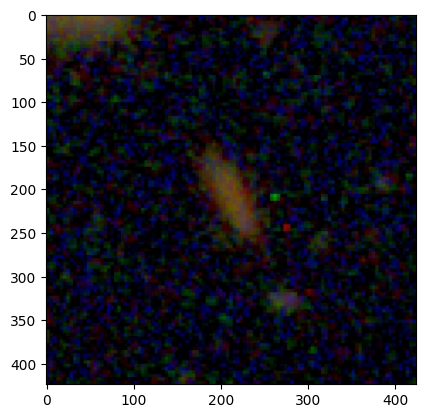

In [4]:
import numpy as np
import matplotlib.pyplot as plt
img, labels = gzdataset[np.random.randint(len(gzdataset))]
plt.imshow(img)
print(labels)
print(img.size)

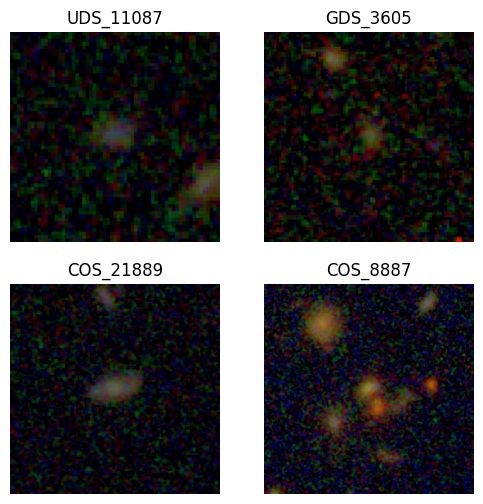

In [5]:
from ml_sandbox.dataset import show_sample_images
for i in range(3,4):
    show_sample_images(gzdataset, num_images=i+1)

In [13]:
from torch.utils.data import random_split
train_dataset, test_dataset = random_split(gzdataset, [0.8, 0.2])

In [14]:
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

train_X = [train_dataset[i][0].numpy().flatten() for i in range(len(train_dataset))]

KeyboardInterrupt: 

In [6]:
from ml_sandbox.models import make_pca_rf_pipeline
model = make_pca_rf_pipeline(n_pca_comp=150, n_trees=100, random_state=42)


In [7]:
from ml_sandbox.dataset import get_sklearn_dataset
from sklearn.model_selection import train_test_split
X, y = get_sklearn_dataset(catalog, label_cols='merging-candels_merger')

xtrain, xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
xtrain

,smooth-or-featured-candels_smooth,smooth-or-featured-candels_features,smooth-or-featured-candels_artifact,how-rounded-candels_completely,how-rounded-candels_in-between,how-rounded-candels_cigar-shaped,clumpy-appearance-candels_yes,clumpy-appearance-candels_no,disk-edge-on-candels_yes,disk-edge-on-candels_no,...,bulge-size-candels_none,bulge-size-candels_obvious,bulge-size-candels_dominant,merging-candels_tidal-debris,merging-candels_both,merging-candels_neither,filename,ra,dec,file_loc
36955,1.0,1.0,37.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,GDS_2171.jpg,53.104880,-27.900988,.tmp/images/GDS_2171.jpg
904,46.0,16.0,15.0,27.0,19.0,0.0,9.0,7.0,2.0,5.0,...,5.0,0.0,0.0,13.0,1.0,40.0,COS_7455.jpg,150.097420,2.268460,.tmp/images/COS_7455.jpg
22943,42.0,14.0,19.0,13.0,29.0,0.0,5.0,9.0,1.0,8.0,...,3.0,5.0,0.0,7.0,2.0,43.0,COS_18576.jpg,150.055410,2.402404,.tmp/images/COS_18576.jpg
22964,23.0,7.0,7.0,4.0,19.0,0.0,1.0,6.0,1.0,5.0,...,0.0,3.0,2.0,2.0,0.0,25.0,COS_19107.jpg,150.060610,2.406473,.tmp/images/COS_19107.jpg
4705,21.0,3.0,13.0,14.0,7.0,0.0,1.0,2.0,1.0,1.0,...,0.0,0.0,1.0,3.0,1.0,19.0,UDS_14448.jpg,34.392312,-5.195929,.tmp/images/UDS_14448.jpg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6265,15.0,5.0,19.0,13.0,2.0,0.0,2.0,3.0,0.0,3.0,...,0.0,3.0,0.0,0.0,0.0,10.0,GDS_25510.jpg,53.066958,-27.693681,.tmp/images/GDS_25510.jpg
11284,8.0,4.0,8.0,4.0,4.0,0.0,4.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,3.0,GDS_25706.jpg,53.138417,-27.694917,.tmp/images/GDS_25706.jpg
38158,21.0,1.0,14.0,13.0,6.0,2.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,1.0,20.0,COS_10435.jpg,150.116090,2.304241,.tmp/images/COS_10435.jpg
860,4.0,2.0,12.0,0.0,4.0,0.0,2.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,5.0,COS_29024.jpg,150.173590,2.553774,.tmp/images/COS_29024.jpg


In [8]:
model.fit(xtrain, ytrain)
test_accuracy = model.score(xtest, ytest)
print(f'Test Accuracy: {test_accuracy:.4f}')


ValueError: could not convert string to float: 'GDS_2171.jpg'